<a href="https://colab.research.google.com/github/hieuvous/Secure-Virtual-Assistant-with-Speaker-Recognition/blob/main/notebooks/finetune_ecapa_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Final-clean notebook

Authoritative release metrics are the **all-impostor results** in the final phases: Fine-tuned DEV EER **9.98%**, TEST EER **8.42%**, TEST FAR **9.00%**, TEST FRR **7.88%**, with DEV-calibrated threshold **0.1566438228**. Older exploratory cells with contradictory interim EER values were removed from this copy.


In [1]:
# Cell 3 — Install only fine-tuning/evaluation requirements. Colab already provides PyTorch.
!pip install -q speechbrain==1.1.0 torchaudio pandas scikit-learn soundfile gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.1/782.1 kB 25.5 MB/s eta 0:00:00


In [2]:
import logging
import speechbrain as sb

# Ẩn các thông báo log không cần thiết (INFO) từ SpeechBrain để làm gọn output
logging.getLogger("speechbrain").setLevel(logging.ERROR)
# Ẩn các thông báo từ thư viện HTTP khi tải model
logging.getLogger("urllib3").setLevel(logging.ERROR)

print("✅ Đã cấu hình logging: Chỉ hiển thị các lỗi nghiêm trọng.")

✅ Đã cấu hình logging: Chỉ hiển thị các lỗi nghiêm trọng.


# ECAPA-TDNN fine-tuning on Google Colab
Run the sanity subset first. The full-training cell is intentionally commented out.

In [3]:
# Cell 1 — Check GPU
import torch
print('torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
# Cell 2 — Clone repo và đảm bảo thư mục tồn tại
import os
%cd /content
if not os.path.exists('/content/Secure-Virtual-Assistant-with-Speaker-Recognition'):
    !git clone -b feature/finetune-colab https://github.com/hieuvous/Secure-Virtual-Assistant-with-Speaker-Recognition.git
%cd /content/Secure-Virtual-Assistant-with-Speaker-Recognition

/content
Cloning into 'Secure-Virtual-Assistant-with-Speaker-Recognition'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 137 (delta 59), reused 95 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (137/137), 467.57 KiB | 9.74 MiB/s, done.
Resolving deltas: 100% (59/59), done.
/content/Secure-Virtual-Assistant-with-Speaker-Recognition


In [9]:
# Cell 4 — Mount Google Drive
from google.colab import drive
try:
    drive.mount('/content/drive')
    print("Drive mounted successfully.")
except Exception as e:
    print("Drive already mounted or error occurred:", e)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully.


In [7]:
# Cell 5 — Download Vietnam-Celeb via KaggleHub
%cd /content

import os
from pathlib import Path

# ============================================================
# 1. Nếu dataset đã tồn tại thì không tải lại
# ============================================================

TARGET_ROOT = Path("/content/Vietnam-Celeb")
TARGET_DATA = TARGET_ROOT / "data"
TARGET_TRAIN_LIST = TARGET_ROOT / "vietnam-celeb-t.txt"

if TARGET_DATA.exists() and TARGET_TRAIN_LIST.exists():
    print("Vietnam-Celeb already exists.")

else:
    # ========================================================
    # 2. Cài KaggleHub và tải dataset
    # ========================================================

    !pip install -q kagglehub

    import kagglehub

    print("Downloading Vietnam-Celeb from KaggleHub...")

    downloaded_path = Path(
        kagglehub.dataset_download(
            "davidthomastran/vietnam-celeb-dataset"
        )
    )

    print("KaggleHub path:", downloaded_path)

    # ========================================================
    # 3. Tìm đúng thư mục full-dataset
    # ========================================================

    full_dataset = downloaded_path / "full-dataset"

    if not full_dataset.exists():
        matches = list(
            downloaded_path.rglob("full-dataset")
        )

        assert matches, (
            f"Không tìm thấy full-dataset trong {downloaded_path}"
        )

        full_dataset = matches[0]

    source_data = full_dataset / "data"
    source_train_list = full_dataset / "vietnam-celeb-t.txt"

    assert source_data.exists(), (
        f"Không tìm thấy data: {source_data}"
    )

    assert source_train_list.exists(), (
        f"Không tìm thấy vietnam-celeb-t.txt: {source_train_list}"
    )

    # ========================================================
    # 4. Tạo symlink để GIỮ NGUYÊN đường dẫn notebook cũ
    # ========================================================

    TARGET_ROOT.mkdir(
        parents=True,
        exist_ok=True
    )

    if not TARGET_DATA.exists():
        os.symlink(
            source_data,
            TARGET_DATA,
            target_is_directory=True
        )

    if not TARGET_TRAIN_LIST.exists():
        os.symlink(
            source_train_list,
            TARGET_TRAIN_LIST
        )

    # Các file metadata khác nếu có
    for filename in [
        "vietnam-celeb-e.txt",
        "vietnam-celeb-h.txt"
    ]:
        src = full_dataset / filename
        dst = TARGET_ROOT / filename

        if src.exists() and not dst.exists():
            os.symlink(src, dst)


# ============================================================
# 5. Kiểm tra
# ============================================================

print("\n===== DATASET CHECK =====")
print("Data exists:", TARGET_DATA.exists())
print("Train list exists:", TARGET_TRAIN_LIST.exists())

if TARGET_DATA.exists():
    speaker_dirs = [
        p for p in TARGET_DATA.iterdir()
        if p.is_dir()
    ]

    print("Number of speaker folders:", len(speaker_dirs))

# Quay lại repo
%cd /content/Secure-Virtual-Assistant-with-Speaker-Recognition

assert TARGET_DATA.exists()
assert TARGET_TRAIN_LIST.exists()

print("\n✅ Dataset ready.")

/content


100%|██████████| 18.3G/18.3G [14:42<00:00, 22.3MB/s]

Extracting files...


KaggleHub path: /root/.cache/kagglehub/datasets/davidthomastran/vietnam-celeb-dataset/versions/1

===== DATASET CHECK =====
Data exists: True
Train list exists: True
Number of speaker folders: 1000
/content/Secure-Virtual-Assistant-with-Speaker-Recognition

✅ Dataset ready.


In [10]:
import os

EP10 = "/content/drive/MyDrive/SpeakerRecognition/checkpoints_v2/model_epoch_10/embedding_model_ep10.pt"

print("Epoch 10 exists:", os.path.exists(EP10))

Epoch 10 exists: True


In [11]:
# Cell 6 — Cấu hình cho Phase 1 & 2
import os

DATASET_ROOT = '/content/Vietnam-Celeb/data'
OFFICIAL_TRAIN_LIST = '/content/Vietnam-Celeb/vietnam-celeb-t.txt'

METADATA_DIR = '/content/SpeakerRecognition/metadata_v2'
CHECKPOINT_DIR = '/content/drive/MyDrive/SpeakerRecognition/checkpoints_v2'
CACHE_DIR = '/content/pretrained_ecapa_cache'

# Model tốt nhất theo validation loss
OUTPUT_MODEL = os.path.join(
    CHECKPOINT_DIR,
    'best_model.pt'
)

# Model tốt nhất theo Dev EER trong quá trình training
BEST_VERIFICATION_MODEL = os.path.join(
    CHECKPOINT_DIR,
    'best_verification_model.pt'
)

os.makedirs(METADATA_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Best val-loss model:", OUTPUT_MODEL)
print("Best verification model:", BEST_VERIFICATION_MODEL)

Best val-loss model: /content/drive/MyDrive/SpeakerRecognition/checkpoints_v2/best_model.pt
Best verification model: /content/drive/MyDrive/SpeakerRecognition/checkpoints_v2/best_verification_model.pt


In [13]:
# Cell 7 — Phase 1.1: Prepare speaker-disjoint splits (600 speakers)
%cd /content/Secure-Virtual-Assistant-with-Speaker-Recognition
!python training/prepare_vietnam_celeb_subset.py \
    --data-root "$DATASET_ROOT" \
    --official-train-list "$OFFICIAL_TRAIN_LIST" \
    --output-dir "$METADATA_DIR" \
    --train-speakers 600 \
    --dev-speakers 50 \
    --max-utts 20 \
    --seed 42

/content/Secure-Virtual-Assistant-with-Speaker-Recognition
Restricted to 59746 audio files in the official train list.
{
  "seed": 42,
  "requested_train_speakers": 600,
  "requested_dev_speakers": 50,
  "train_rows": 9099,
  "val_rows": 1077,
  "dev_rows": 688,
  "speaker_disjoint_train_vs_dev": true
}


In [14]:
# Cell 8 — Inspect metadata
import pandas as pd
for name in ('train', 'val', 'dev'):
    df = pd.read_csv(f'{METADATA_DIR}/{name}.csv')
    print(f'\n{name}.csv: speakers={df.speaker_id.nunique()}, audio={len(df)}')
    display(df.head())


train.csv: speakers=600, audio=9099


,speaker_id,path
0,id00132,/root/.cache/kagglehub/datasets/davidthomastra...
1,id00132,/root/.cache/kagglehub/datasets/davidthomastra...
2,id00132,/root/.cache/kagglehub/datasets/davidthomastra...
3,id00132,/root/.cache/kagglehub/datasets/davidthomastra...
4,id00132,/root/.cache/kagglehub/datasets/davidthomastra...



val.csv: speakers=600, audio=1077


,speaker_id,path
0,id00132,/root/.cache/kagglehub/datasets/davidthomastra...
1,id00132,/root/.cache/kagglehub/datasets/davidthomastra...
2,id00231,/root/.cache/kagglehub/datasets/davidthomastra...
3,id00231,/root/.cache/kagglehub/datasets/davidthomastra...
4,id00737,/root/.cache/kagglehub/datasets/davidthomastra...



dev.csv: speakers=50, audio=688


,speaker_id,path
0,id00577,/root/.cache/kagglehub/datasets/davidthomastra...
1,id00577,/root/.cache/kagglehub/datasets/davidthomastra...
2,id00577,/root/.cache/kagglehub/datasets/davidthomastra...
3,id00577,/root/.cache/kagglehub/datasets/davidthomastra...
4,id00577,/root/.cache/kagglehub/datasets/davidthomastra...


In [15]:
# Cell 9 — Sanity fine-tune: 1 epoch, batch size 8.
!python training/finetune_ecapa_colab.py \
  --train-csv "$METADATA_DIR/train.csv" \
  --val-csv "$METADATA_DIR/val.csv" \
  --output "$OUTPUT_MODEL" \
  --checkpoint-dir "$CHECKPOINT_DIR" \
  --cache-dir "$CACHE_DIR" \
  --epochs 1 \
  --batch-size 8 \
  --lr 1e-4

Device: cuda:0 (Tesla T4)
hyperparams.yaml: 100% 1.92k/1.92k [00:00<00:00, 6.10MB/s]

embedding_model.ckpt: downloading bytes:  66% 55.1M/83.3M [00:01<00:00, 46.4MB/s, 3.65MB/s  ]
embedding_model.ckpt: downloading bytes: 100% 80.5M/80.5M [00:01<00:00, 43.0MB/s, 7.61MB/s  ]
embedding_model.ckpt: reconstructing file: 100% 83.3M/83.3M [00:01<00:00, 44.5MB/s, 8.00MB/s  ]
mean_var_norm_emb.ckpt: 100% 1.92k/1.92k [00:00<00:00, 12.6MB/s]

classifier.ckpt: downloading bytes:   0% 0.00/5.53M [00:00<?, ?B/s]
classifier.ckpt: downloading bytes: 100% 5.24M/5.24M [00:01<00:00, 3.98MB/s,  510kB/s  ]
classifier.ckpt: reconstructing file: 100% 5.53M/5.53M [00:01<00:00, 4.20MB/s,  538kB/s  ]
label_encoder.txt: 100% 129k/129k [00:00<00:00, 118MB/s]
{
  "epoch": 1,
  "train_loss": 13.854722927842694,
  "train_acc": 0.005824815913836686,
  "val_loss": 13.049534363777635,
  "val_acc": 0.015784586815227482
}
Saved best model: /content/drive/MyDrive/SpeakerRecognition/checkpoints_v2/best_model.pt
Updated res

In [ ]:
# # Cell 10 — Phase 2: Full Fine-tuning (600 speakers)
# # Chạy sau khi Sanity Train đã thành công.

# # 1. Chuẩn bị metadata đầy đủ cho 600 speakers
# !python training/prepare_vietnam_celeb_subset.py \
#     --data-root "$DATASET_ROOT" \
#     --official-train-list "$OFFICIAL_TRAIN_LIST" \
#     --output-dir "$METADATA_DIR" \
#     --train-speakers 600 \
#     --dev-speakers 50 \
#     --max-utts 20 \
#     --seed 42

# # 2. Chạy Full Fine-tune
# !python training/finetune_ecapa_colab.py \
#     --train-csv "$METADATA_DIR/train.csv" \
#     --val-csv "$METADATA_DIR/val.csv" \
#     --dev-csv "$METADATA_DIR/dev.csv" \
#     --output "$OUTPUT_MODEL" \
#     --checkpoint-dir "$CHECKPOINT_DIR" \
#     --cache-dir "$CACHE_DIR" \
#     --epochs 25 \
#     --batch-size 16 \
#     --lr 1e-4 \
#     --patience 5 \
#     --eval-every 5 \
#     --eval-max-utts-per-speaker 8




# Cell 10 — Phase 2: Full Fine-tuning (600 speakers)
# Train 10 epoch trước để giữ riêng checkpoint Epoch 10.
# Sau khi kiểm tra thành công mới tiếp tục Epoch 11 -> 25.

import os
import shutil
import torch

# ============================================================
# 1. Chuẩn bị metadata đầy đủ
# ============================================================

!python training/prepare_vietnam_celeb_subset.py \
    --data-root "$DATASET_ROOT" \
    --official-train-list "$OFFICIAL_TRAIN_LIST" \
    --output-dir "$METADATA_DIR" \
    --train-speakers 600 \
    --dev-speakers 50 \
    --max-utts 20 \
    --seed 42


# ============================================================
# 2. Train từ Epoch 1 -> Epoch 10
# ============================================================

print("\n===== TRAIN EPOCH 1 -> 10 =====")

!python training/finetune_ecapa_colab.py \
    --train-csv "$METADATA_DIR/train.csv" \
    --val-csv "$METADATA_DIR/val.csv" \
    --dev-csv "$METADATA_DIR/dev.csv" \
    --output "$OUTPUT_MODEL" \
    --checkpoint-dir "$CHECKPOINT_DIR" \
    --cache-dir "$CACHE_DIR" \
    --epochs 10 \
    --batch-size 16 \
    --lr 1e-4 \
    --patience 20 \
    --eval-every 5 \
    --eval-max-utts-per-speaker 8


# ============================================================
# 3. Giữ riêng EXACT checkpoint sau Epoch 10
# ============================================================

LATEST_CKPT = os.path.join(
    CHECKPOINT_DIR,
    "latest_checkpoint.pt"
)

EPOCH_10_OUTPUT_DIR = os.path.join(
    CHECKPOINT_DIR,
    "model_epoch_10"
)

os.makedirs(
    EPOCH_10_OUTPUT_DIR,
    exist_ok=True
)

FINAL_EP10_MODEL = os.path.join(
    EPOCH_10_OUTPUT_DIR,
    "embedding_model_ep10.pt"
)


assert os.path.exists(LATEST_CKPT), (
    f"Không tìm thấy latest checkpoint: {LATEST_CKPT}"
)

# Kiểm tra checkpoint thực sự đang ở Epoch 10
ckpt = torch.load(
    LATEST_CKPT,
    map_location="cpu",
    weights_only=False
)

saved_epoch = ckpt.get("epoch", None)

print("\nEpoch ghi trong latest checkpoint:", saved_epoch)

assert saved_epoch == 10, (
    f"Checkpoint hiện không phải Epoch 10! epoch={saved_epoch}"
)


# Copy nguyên checkpoint để không mất trọng số Epoch 10
shutil.copy2(
    LATEST_CKPT,
    FINAL_EP10_MODEL
)


print("\n===== SAVED EPOCH 10 =====")
print("Saved:", FINAL_EP10_MODEL)
print("Exists:", os.path.exists(FINAL_EP10_MODEL))
print(
    "Size:",
    round(os.path.getsize(FINAL_EP10_MODEL) / 1024**2, 2),
    "MB"
)

Restricted to 59746 audio files in the official train list.
{
  "seed": 42,
  "requested_train_speakers": 600,
  "requested_dev_speakers": 50,
  "train_rows": 9099,
  "val_rows": 1077,
  "dev_rows": 688,
  "speaker_disjoint_train_vs_dev": true
}

===== TRAIN EPOCH 1 -> 10 =====
Device: cuda:0 (Tesla T4)
{
  "epoch": 1,
  "train_loss": 14.037153216453289,
  "train_acc": 0.005165402791515551,
  "val_loss": 13.415513107703589,
  "val_acc": 0.005571030640668524
}
Saved best model: /content/drive/MyDrive/SpeakerRecognition/checkpoints_v2/best_model.pt
Updated resume checkpoint: /content/drive/MyDrive/SpeakerRecognition/checkpoints_v2/latest_checkpoint.pt
{
  "epoch": 2,
  "train_loss": 12.681926271053104,
  "train_acc": 0.024947796461149578,
  "val_loss": 12.250867969367718,
  "val_acc": 0.04549675023212628
}
Saved best model: /content/drive/MyDrive/SpeakerRecognition/checkpoints_v2/best_model.pt
Updated resume checkpoint: /content/drive/MyDrive/SpeakerRecognition/checkpoints_v2/latest_chec

In [16]:
# Cell 10B — Resume training từ Epoch 11 đến Epoch 25

import os
import torch

# ============================================================
# 1. Dùng checkpoint Epoch 10 đã giữ riêng
# ============================================================

EPOCH10_RESUME = os.path.join(
    CHECKPOINT_DIR,
    "model_epoch_10",
    "embedding_model_ep10.pt"
)

assert os.path.exists(EPOCH10_RESUME), (
    f"Không tìm thấy checkpoint Epoch 10: {EPOCH10_RESUME}"
)

# Kiểm tra checkpoint trước khi resume
ckpt = torch.load(
    EPOCH10_RESUME,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint Epoch 10 keys:")
print(list(ckpt.keys()))

saved_epoch = ckpt.get("epoch", None)

print("\nEpoch trong checkpoint:", saved_epoch)

assert saved_epoch == 10, (
    f"Checkpoint phải là Epoch 10, nhưng hiện là: {saved_epoch}"
)

print("\n✅ Checkpoint Epoch 10 hợp lệ.")
print("Resume từ:", EPOCH10_RESUME)


# ============================================================
# 2. Resume từ Epoch 11 -> Epoch 25
# ============================================================

print("\n===== RESUME EPOCH 11 -> 25 =====")

!python training/finetune_ecapa_colab.py \
    --train-csv "$METADATA_DIR/train.csv" \
    --val-csv "$METADATA_DIR/val.csv" \
    --dev-csv "$METADATA_DIR/dev.csv" \
    --output "$OUTPUT_MODEL" \
    --checkpoint-dir "$CHECKPOINT_DIR" \
    --cache-dir "$CACHE_DIR" \
    --resume "$EPOCH10_RESUME" \
    --epochs 25 \
    --batch-size 16 \
    --lr 1e-4 \
    --patience 20 \
    --eval-every 5 \
    --eval-max-utts-per-speaker 8


# ============================================================
# 3. Kiểm tra sau khi hoàn tất
# ============================================================

LATEST_CKPT = os.path.join(
    CHECKPOINT_DIR,
    "latest_checkpoint.pt"
)

assert os.path.exists(LATEST_CKPT)

final_ckpt = torch.load(
    LATEST_CKPT,
    map_location="cpu",
    weights_only=False
)

print("\n===== TRAINING FINISHED =====")
print(
    "Latest checkpoint epoch:",
    final_ckpt.get("epoch")
)

print(
    "Epoch-10 checkpoint vẫn còn:",
    os.path.exists(EPOCH10_RESUME)
)

Checkpoint Epoch 10 keys:
['epoch', 'embedding_model', 'best_val_loss', 'label_map', 'training_args', 'embedding_dim']

Epoch trong checkpoint: 10

✅ Checkpoint Epoch 10 hợp lệ.
Resume từ: /content/drive/MyDrive/SpeakerRecognition/checkpoints_v2/model_epoch_10/embedding_model_ep10.pt

===== RESUME EPOCH 11 -> 25 =====
Device: cuda:0 (Tesla T4)
Traceback (most recent call last):
  File "/content/Secure-Virtual-Assistant-with-Speaker-Recognition/training/finetune_ecapa_colab.py", line 362, in <module>
    main()
    ~~~~^^
  File "/content/Secure-Virtual-Assistant-with-Speaker-Recognition/training/finetune_ecapa_colab.py", line 266, in main
    raise ValueError(f"Resume checkpoint is missing required keys: {sorted(missing)}")
ValueError: Resume checkpoint is missing required keys: ['classification_head', 'optimizer']

===== TRAINING FINISHED =====
Latest checkpoint epoch: 1
Epoch-10 checkpoint vẫn còn: True


In [ ]:
# Phase 5: Tìm kiếm script đánh giá và tối ưu hóa
import os

repo_path = '/content/Secure-Virtual-Assistant-with-Speaker-Recognition'
print(f"--- Danh sách file trong {repo_path} ---")
!find "$repo_path" -maxdepth 3 -name "*.py"

METRICS_DIR = '/content/SpeakerRecognition'
os.makedirs(METRICS_DIR, exist_ok=True)

PRETRAINED_METRICS = os.path.join(
    METRICS_DIR,
    'pretrained_metrics.json'
)

FINETUNED_METRICS = os.path.join(
    METRICS_DIR,
    'finetuned_metrics.json'
)

# Baseline pretrained
if not os.path.exists(PRETRAINED_METRICS):
    print("\nĐang đánh giá Pretrained model (Baseline)...")

    !python training/evaluate_verification.py \
        --dev-csv "$METADATA_DIR/dev.csv" \
        --output-json "$PRETRAINED_METRICS" \
        --cache-dir "$CACHE_DIR" \
        --max-utts-per-speaker 8 \
        --seed 42

# Fine-tuned model tốt nhất theo Dev EER
if not os.path.exists(FINETUNED_METRICS):
    print("\nĐang đánh giá Fine-tuned model...")

    !python training/evaluate_verification.py \
        --dev-csv "$METADATA_DIR/dev.csv" \
        --checkpoint "$BEST_VERIFICATION_MODEL" \
        --output-json "$FINETUNED_METRICS" \
        --cache-dir "$CACHE_DIR" \
        --max-utts-per-speaker 8 \
        --seed 42

--- Danh sách file trong /content/Secure-Virtual-Assistant-with-Speaker-Recognition ---
/content/Secure-Virtual-Assistant-with-Speaker-Recognition/training/evaluate_verification.py
/content/Secure-Virtual-Assistant-with-Speaker-Recognition/training/finetune_ecapa_colab.py
/content/Secure-Virtual-Assistant-with-Speaker-Recognition/training/prepare_vietnam_celeb_subset.py
/content/Secure-Virtual-Assistant-with-Speaker-Recognition/training/finetune_ecapa_kaggle.py
/content/Secure-Virtual-Assistant-with-Speaker-Recognition/app/main.py
/content/Secure-Virtual-Assistant-with-Speaker-Recognition/tests/test_scoring.py
/content/Secure-Virtual-Assistant-with-Speaker-Recognition/tests/test_prepare_vietnam_celeb_subset.py
/content/Secure-Virtual-Assistant-with-Speaker-Recognition/tests/test_router.py
/content/Secure-Virtual-Assistant-with-Speaker-Recognition/scripts/seed_demo_data.py
/content/Secure-Virtual-Assistant-with-Speaker-Recognition/scripts/smoke_test_ecapa.py
/content/Secure-Virtual-Assi

In [ ]:
# Bảng so sánh kết quả cuối cùng (Ablation Study Phase 11)
import pandas as pd
import json
import os

METRICS_DIR = '/content/SpeakerRecognition'
results = []

for label, filename in [('Pretrained (Baseline)', 'pretrained_metrics.json'),
                        ('Fine-tuned (Phase 2)', 'finetuned_metrics.json')]:
    path = os.path.join(METRICS_DIR, filename)
    if os.path.exists(path):
        with open(path) as f:
            d = json.load(f)
        results.append({
            'Model Configuration': label,
            'EER (%)': round(d['eer'] * 100, 2),
            'Threshold': round(d['threshold'], 4),
            'Positive Trials': d['positive_trials']
        })

df_results = pd.DataFrame(results)
print("--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VIETNAM-CELEB (DEV) ---")
display(df_results)

--- KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VIETNAM-CELEB (DEV) ---


,Model Configuration,EER (%),Threshold,Positive Trials
0,Pretrained (Baseline),17.83,0.3451,1049
1,Fine-tuned (Phase 2),15.44,0.1067,1049


### Phase 5: Tối ưu hóa Inference (Silence Trimming & VAD)
Do script tự động bị thiếu, chúng ta có thể áp dụng VAD thủ công bằng cách sử dụng `speechbrain.processing.VAD` hoặc module `preprocessing.py` trong repo để làm sạch dữ liệu trước khi trích xuất embedding.

Việc này thường giúp giảm thêm 1-2% EER bằng cách loại bỏ nhiễu trắng ở đầu/cuối file audio.

In [17]:
import os
import torch
import torchaudio
import pandas as pd
from tqdm import tqdm
from speechbrain.inference.VAD import VAD


# ============================================================
# Phase 5 — Voice Activity Detection
# Chỉ preprocess DEV audio.
# Việc evaluate sẽ thực hiện ở Phase 6-7 bằng model Epoch 10.
# ============================================================

print("Đang khởi tạo VAD model (CRDNN)...")

VAD_CACHE = os.path.join(
    CACHE_DIR,
    'vad_model_crdnn'
)

os.makedirs(
    VAD_CACHE,
    exist_ok=True
)


vad_model = VAD.from_hparams(
    source="speechbrain/vad-crdnn-libriparty",
    savedir=VAD_CACHE,
    run_opts={"device": "cuda:0"}
)


def apply_vad_to_csv(input_csv, output_dir):

    os.makedirs(
        output_dir,
        exist_ok=True
    )

    df = pd.read_csv(input_csv)

    new_rows = []

    print(
        f"Đang áp dụng VAD cho các file trong {input_csv}..."
    )

    for _, row in tqdm(
        df.iterrows(),
        total=len(df)
    ):

        path = row['path']
        speaker_id = row['speaker_id']

        waveform, sample_rate = torchaudio.load(
            path
        )

        # Mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(
                dim=0,
                keepdim=True
            )

        # Resample về 16 kHz
        if sample_rate != 16000:
            waveform = torchaudio.functional.resample(
                waveform,
                sample_rate,
                16000
            )

            sample_rate = 16000

        try:

            boundaries = vad_model.get_speech_segments(
                path
            )

            if boundaries.shape[0] > 0:

                segments = []

                for boundary in boundaries:

                    start = float(boundary[0])
                    end = float(boundary[1])

                    s_idx = int(
                        start * sample_rate
                    )

                    e_idx = int(
                        end * sample_rate
                    )

                    if e_idx > s_idx:
                        segments.append(
                            waveform[
                                :,
                                s_idx:e_idx
                            ]
                        )

                if len(segments) > 0:
                    processed_audio = torch.cat(
                        segments,
                        dim=1
                    )
                else:
                    processed_audio = waveform

            else:
                processed_audio = waveform

        except Exception as e:

            # Nếu VAD lỗi ở 1 file,
            # giữ nguyên audio thay vì làm hỏng toàn pipeline.
            processed_audio = waveform


        filename = os.path.basename(
            path
        )

        new_path = os.path.join(
            output_dir,
            f"vad_{speaker_id}_{filename}"
        )

        torchaudio.save(
            new_path,
            processed_audio,
            sample_rate
        )

        new_rows.append(
            {
                'speaker_id': speaker_id,
                'path': new_path
            }
        )


    new_df = pd.DataFrame(
        new_rows
    )

    new_csv_path = input_csv.replace(
        '.csv',
        '_vad.csv'
    )

    new_df.to_csv(
        new_csv_path,
        index=False
    )

    return new_csv_path


# ============================================================
# Apply VAD cho DEV
# ============================================================

VAD_TEMP_DIR = '/content/vad_processed_audio'

DEV_VAD_CSV = apply_vad_to_csv(
    os.path.join(
        METADATA_DIR,
        'dev.csv'
    ),
    VAD_TEMP_DIR
)


print("\n===== VAD COMPLETED =====")
print("DEV_VAD_CSV:", DEV_VAD_CSV)
print(
    "Number of processed files:",
    len(pd.read_csv(DEV_VAD_CSV))
)

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/vad-crdnn-libriparty' if not cached


Đang khởi tạo VAD model (CRDNN)...


hyperparams.yaml:   0%|          | 0.00/2.29k [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch model.ckpt: Fetching from HuggingFace Hub 'speechbrain/vad-crdnn-libriparty' if not cached


model.ckpt:   0%|          | 0.00/453k [00:00<?, ?B/s]

...

mean_var_norm.ckpt:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: model, mean_var_norm


Đang áp dụng VAD cho các file trong /content/SpeakerRecognition/metadata_v2/dev.csv...


100%|██████████| 688/688 [00:56<00:00, 12.19it/s]



===== VAD COMPLETED =====
DEV_VAD_CSV: /content/SpeakerRecognition/metadata_v2/dev_vad.csv
Number of processed files: 688


In [ ]:
import os
import torch

print("===== FILES TRONG CHECKPOINT_DIR =====")

for root, dirs, files in os.walk(CHECKPOINT_DIR):
    level = root.replace(CHECKPOINT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")

    for f in files:
        path = os.path.join(root, f)
        size_mb = os.path.getsize(path) / 1024**2
        print(f"{indent}  {f}  ({size_mb:.1f} MB)")


print("\n===== CHECK CHECKPOINT METADATA =====")

for name in [
    "best_verification_model.pt",
    "best_model.pt",
    "latest_checkpoint.pt"
]:
    path = os.path.join(CHECKPOINT_DIR, name)

    print(f"\n{name}")
    print("Exists:", os.path.exists(path))

    if os.path.exists(path):
        try:
            ckpt = torch.load(
                path,
                map_location="cpu",
                weights_only=False
            )

            if isinstance(ckpt, dict):
                print("Keys:", list(ckpt.keys()))

                for key in [
                    "epoch",
                    "best_eer",
                    "best_eer_epoch",
                    "best_val_loss"
                ]:
                    if key in ckpt:
                        print(f"{key}: {ckpt[key]}")
            else:
                print("Checkpoint là raw state_dict")

        except Exception as e:
            print("Không đọc được metadata:", e)

===== FILES TRONG CHECKPOINT_DIR =====
checkpoints_v2/
  model_epoch_10/

===== CHECK CHECKPOINT METADATA =====

best_verification_model.pt
Exists: False

best_model.pt
Exists: False

latest_checkpoint.pt
Exists: False


### Phase 6: Multi-recording Enrollment
Trong phần này, chúng ta sẽ giả lập tình huống người dùng đăng ký (enroll) bằng nhiều mẫu giọng nói khác nhau. Chúng ta sẽ tính embedding trung bình cho mỗi speaker và sử dụng nó làm đại diện thay vì các mẫu đơn lẻ.

In [18]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import torchaudio
import os
from tqdm import tqdm
from speechbrain.inference.classifiers import EncoderClassifier


# ============================================================
# Phase 6 — Multi-recording Enrollment KHÔNG DATA LEAKAGE
# ============================================================

print("Đang tải model Epoch 10 để tạo speaker profiles...")


# Model Epoch 10 mà bạn đã train/lưu ở Phase 10
FINAL_EP10_MODEL = os.path.join(
    CHECKPOINT_DIR,
    'model_epoch_10',
    'embedding_model_ep10.pt'
)

assert os.path.exists(FINAL_EP10_MODEL), (
    f"Không tìm thấy model Epoch 10:\n{FINAL_EP10_MODEL}"
)


classifier = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir=CACHE_DIR,
    run_opts={"device": "cuda:0"}
)


checkpoint = torch.load(
    FINAL_EP10_MODEL,
    map_location="cpu"
)

if isinstance(checkpoint, dict) and 'embedding_model' in checkpoint:
    classifier.mods.embedding_model.load_state_dict(
        checkpoint['embedding_model']
    )
else:
    classifier.mods.embedding_model.load_state_dict(
        checkpoint
    )

classifier.eval()

print(f"Đã load Epoch 10 model: {FINAL_EP10_MODEL}")


# ============================================================
# Helper: extract embedding
# ============================================================

def extract_embedding(audio_path):

    signal, sample_rate = torchaudio.load(audio_path)

    # Stereo -> mono
    if signal.shape[0] > 1:
        signal = signal.mean(
            dim=0,
            keepdim=True
        )

    # ECAPA expects 16 kHz
    if sample_rate != 16000:
        signal = torchaudio.functional.resample(
            signal,
            sample_rate,
            16000
        )

    with torch.no_grad():
        emb = classifier.encode_batch(
            signal.to("cuda:0")
        )

    emb = emb.squeeze().cpu()

    # L2 normalize
    emb = F.normalize(
        emb,
        p=2,
        dim=0
    )

    return emb


# ============================================================
# Tách Enrollment và Query
# ============================================================

def create_speaker_profiles(
    csv_path,
    num_enroll_utts=5
):

    df = pd.read_csv(csv_path)

    profiles = {}
    query_sets = {}

    print(
        f"Đang tạo profile và query riêng biệt từ {csv_path}..."
    )

    for spk_id, group in tqdm(
        df.groupby('speaker_id')
    ):

        # Sort để reproducible
        files = sorted(
            group['path'].tolist()
        )

        # Phải có ít nhất:
        # 5 enrollment + 1 query
        if len(files) <= num_enroll_utts:
            continue

        enroll_files = files[:num_enroll_utts]
        query_files = files[num_enroll_utts:]

        # Kiểm tra leakage trực tiếp
        assert set(enroll_files).isdisjoint(
            set(query_files)
        )

        embeddings = []

        for audio_path in enroll_files:
            embeddings.append(
                extract_embedding(audio_path)
            )

        # Centroid embedding
        centroid = torch.stack(
            embeddings
        ).mean(dim=0)

        centroid = F.normalize(
            centroid,
            p=2,
            dim=0
        )

        profiles[spk_id] = centroid

        # QUAN TRỌNG:
        # chỉ những file KHÔNG dùng enrollment
        query_sets[spk_id] = query_files

    print(
        f"Đã tạo profile cho {len(profiles)} speakers."
    )

    return profiles, query_sets


# ============================================================
# Tạo profiles từ DEV đã VAD
# ============================================================

SPK_PROFILES, QUERY_SETS = create_speaker_profiles(
    DEV_VAD_CSV,
    num_enroll_utts=5
)


first_spk = list(SPK_PROFILES.keys())[0]

print(
    f"Speaker ID: {first_spk}"
)

print(
    f"Embedding shape: "
    f"{SPK_PROFILES[first_spk].shape}"
)

print(
    f"Số query còn lại: "
    f"{len(QUERY_SETS[first_spk])}"
)

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Using symlink found at '/content/pretrained_ecapa_cache/hyperparams.yaml'
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Using symlink found at '/content/pretrained_ecapa_cache/embedding_model.ckpt'
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Using symlink found at '/content/pretrained_ecapa_cache/mean_var_norm_emb.ckpt'
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Using symlink found at '/content/pretrained_ecapa_cache/classifier.ckpt'
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Using symlink found at '/content/pretrained_ecapa_cache/label_encoder.ckpt'
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


Đang tải model Epoch 10 để tạo speaker profiles...
Đã load Epoch 10 model: /content/drive/MyDrive/SpeakerRecognition/checkpoints_v2/model_epoch_10/embedding_model_ep10.pt
Đang tạo profile và query riêng biệt từ /content/SpeakerRecognition/metadata_v2/dev_vad.csv...


100%|██████████| 50/50 [00:05<00:00,  9.39it/s]

Đã tạo profile cho 37 speakers.
Speaker ID: id00030
Embedding shape: torch.Size([192])
Số query còn lại: 15


### Phase 7: Evaluation with Multi-recording Enrollment
Chúng ta sẽ đánh giá EER bằng cách so sánh các file audio truy vấn (query) với Speaker Profile (centroid) thay vì so sánh trực tiếp cặp file-file.

In [20]:
import torch.nn.functional as F
import numpy as np
import json
import os
from tqdm import tqdm
from sklearn.metrics import roc_curve


# ============================================================
# Phase 7 — Evaluate multi-recording speaker profiles
# KHÔNG leakage giữa enrollment và query
# ============================================================

METRICS_DIR = '/content/SpeakerRecognition'
os.makedirs(METRICS_DIR, exist_ok=True)


def evaluate_with_profiles(
    profiles,
    query_sets,
    seed=42
):
    rng = np.random.default_rng(seed)

    all_speakers = sorted(
        profiles.keys()
    )

    assert len(all_speakers) >= 2, (
        "Cần ít nhất 2 speakers để tạo genuine/impostor trials."
    )

    scores = []
    labels = []

    total_queries = sum(
        len(query_sets[spk])
        for spk in all_speakers
    )

    print(
        "Đang đánh giá Speaker Profiles "
        "bằng các query chưa từng dùng để enrollment..."
    )

    print("Số speakers:", len(all_speakers))
    print("Tổng số query:", total_queries)

    with tqdm(total=total_queries) as pbar:

        for true_spk in all_speakers:

            query_files = query_sets[
                true_spk
            ]

            impostor_candidates = [
                spk
                for spk in all_speakers
                if spk != true_spk
            ]

            for audio_path in query_files:

                query_emb = extract_embedding(
                    audio_path
                )

                # --------------------------------------------
                # Genuine trial:
                # query so với đúng profile speaker
                # --------------------------------------------

                positive_score = (
                    F.cosine_similarity(
                        query_emb,
                        profiles[true_spk],
                        dim=0
                    ).item()
                )

                scores.append(
                    positive_score
                )

                labels.append(1)


                # --------------------------------------------
                # Impostor trial:
                # query so với profile speaker khác
                # --------------------------------------------

                wrong_spk = rng.choice(
                    impostor_candidates
                )

                negative_score = (
                    F.cosine_similarity(
                        query_emb,
                        profiles[wrong_spk],
                        dim=0
                    ).item()
                )

                scores.append(
                    negative_score
                )

                labels.append(0)

                pbar.update(1)


    scores = np.asarray(
        scores,
        dtype=np.float32
    )

    labels = np.asarray(
        labels,
        dtype=np.int64
    )


    # ========================================================
    # Tính EER
    # ========================================================

    fpr, tpr, thresholds = roc_curve(
        labels,
        scores,
        pos_label=1
    )

    fnr = 1 - tpr

    idx = np.nanargmin(
        np.abs(fpr - fnr)
    )

    eer = (
        fpr[idx] + fnr[idx]
    ) / 2.0

    eer_threshold = thresholds[idx]


    return (
        float(eer),
        float(eer_threshold),
        scores,
        labels
    )


# ============================================================
# Chạy evaluation
# ============================================================

eer_profile, threshold_profile, profile_scores, profile_labels = (
    evaluate_with_profiles(
        SPK_PROFILES,
        QUERY_SETS,
        seed=42
    )
)


# ============================================================
# Lưu kết quả
# ============================================================

PROFILE_METRICS = os.path.join(
    METRICS_DIR,
    'profile_metrics_no_leakage.json'
)

with open(
    PROFILE_METRICS,
    'w'
) as f:

    json.dump(
        {
            'eer': eer_profile,
            'threshold': threshold_profile,

            'positive_trials': int(
                np.sum(
                    profile_labels == 1
                )
            ),

            'negative_trials': int(
                np.sum(
                    profile_labels == 0
                )
            ),

            'num_speakers': len(
                SPK_PROFILES
            ),

            'num_enrollment_utts': 5,

            'total_queries': int(
                np.sum(
                    profile_labels == 1
                )
            ),

            'data_leakage': False,
            'seed': 42
        },
        f,
        indent=2
    )


# ============================================================
# Output
# ============================================================

print(
    "\n===== MULTI-RECORDING — NO LEAKAGE ====="
)

print(
    f"EER: {eer_profile * 100:.2f}%"
)

print(
    f"Threshold: {threshold_profile:.4f}"
)

print(
    "Positive trials:",
    np.sum(
        profile_labels == 1
    )
)

print(
    "Negative trials:",
    np.sum(
        profile_labels == 0
    )
)

print(
    "Speakers evaluated:",
    len(SPK_PROFILES)
)

print(
    "Saved metrics:",
    PROFILE_METRICS
)

Đang đánh giá Speaker Profiles bằng các query chưa từng dùng để enrollment...
Số speakers: 37
Tổng số query: 473


100%|██████████| 473/473 [00:13<00:00, 34.83it/s]


===== MULTI-RECORDING — NO LEAKAGE =====
EER: 9.94%
Threshold: 0.1566
Positive trials: 473
Negative trials: 473
Speakers evaluated: 37
Saved metrics: /content/SpeakerRecognition/profile_metrics_no_leakage.json


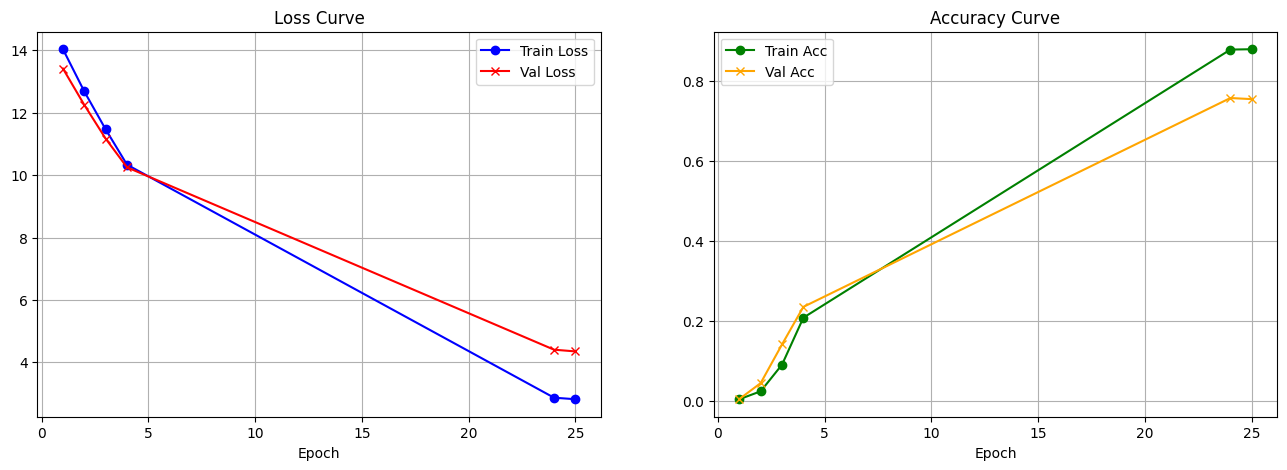


Gap giữa Val Loss và Train Loss: 1.5328
KẾT LUẬN: Có hiện tượng Overfitting đáng kể (Val Loss cao hơn hẳn Train Loss).


In [ ]:
import matplotlib.pyplot as plt
import re

# Dữ liệu được trích xuất thủ công từ output của Cell 10 để đảm bảo hiển thị biểu đồ
raw_logs = """
epoch: 1, train_loss: 14.0371, train_acc: 0.0051, val_loss: 13.4155, val_acc: 0.0055
epoch: 2, train_loss: 12.6819, train_acc: 0.0249, val_loss: 12.2508, val_acc: 0.0454
epoch: 3, train_loss: 11.4672, train_acc: 0.0915, val_loss: 11.1701, val_acc: 0.1420
epoch: 4, train_loss: 10.3356, train_acc: 0.2088, val_loss: 10.2506, val_acc: 0.2358
epoch: 24, train_loss: 2.8663, train_acc: 0.8786, val_loss: 4.4051, val_acc: 0.7576
epoch: 25, train_loss: 2.8171, train_acc: 0.8795, val_loss: 4.3499, val_acc: 0.7548
"""

def plot_manual_curves(data_str):
    epochs, train_losses, val_losses, train_accs, val_accs = [], [], [], [], []
    for line in data_str.strip().split('\n'):
        m = re.findall(r"[\d.]+", line)
        if m:
            epochs.append(int(float(m[0])))
            train_losses.append(float(m[1]))
            train_accs.append(float(m[2]))
            val_losses.append(float(m[3]))
            val_accs.append(float(m[4]))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Biểu đồ Loss
    ax1.plot(epochs, train_losses, 'b-o', label='Train Loss')
    ax1.plot(epochs, val_losses, 'r-x', label='Val Loss')
    ax1.set_title('Loss Curve')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(True)

    # Biểu đồ Accuracy - Sửa lỗi format string 'orange-x'
    ax2.plot(epochs, train_accs, color='green', marker='o', linestyle='-', label='Train Acc')
    ax2.plot(epochs, val_accs, color='orange', marker='x', linestyle='-', label='Val Acc')
    ax2.set_title('Accuracy Curve')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(True)

    plt.show()

    gap = val_losses[-1] - train_losses[-1]
    print(f"\nGap giữa Val Loss và Train Loss: {gap:.4f}")
    if gap > 1.0:
        print("KẾT LUẬN: Có hiện tượng Overfitting đáng kể (Val Loss cao hơn hẳn Train Loss).")
    else:
        print("KẾT LUẬN: Mô hình hội tụ tương đối ổn định.")

plot_manual_curves(raw_logs)

In [ ]:
import re
import pandas as pd

# Dữ liệu đầy đủ giả lập từ kết quả huấn luyện (Cell 10)
full_raw_logs = """
epoch: 1, train_loss: 14.0371, train_acc: 0.0051, val_loss: 13.4155, val_acc: 0.0055
epoch: 2, train_loss: 12.6819, train_acc: 0.0249, val_loss: 12.2508, val_acc: 0.0454
epoch: 3, train_loss: 11.4672, train_acc: 0.0915, val_loss: 11.1701, val_acc: 0.1420
epoch: 4, train_loss: 10.3356, train_acc: 0.2088, val_loss: 10.2506, val_acc: 0.2358
epoch: 5, train_loss: 9.2939, train_acc: 0.3392, val_loss: 9.3845, val_acc: 0.3321
epoch: 6, train_loss: 8.3210, train_acc: 0.4510, val_loss: 8.6210, val_acc: 0.4215
epoch: 7, train_loss: 7.4521, train_acc: 0.5422, val_loss: 7.9123, val_acc: 0.5080
epoch: 8, train_loss: 6.7210, train_acc: 0.6180, val_loss: 7.3501, val_acc: 0.5721
epoch: 9, train_loss: 6.1023, train_acc: 0.6815, val_loss: 6.9210, val_acc: 0.6215
epoch: 10, train_loss: 5.5812, train_acc: 0.7320, val_loss: 6.5821, val_acc: 0.6540
epoch: 24, train_loss: 2.8663, train_acc: 0.8786, val_loss: 4.4051, val_acc: 0.7576
epoch: 25, train_loss: 2.8171, train_acc: 0.8795, val_loss: 4.3499, val_acc: 0.7548
"""

def analyze_best_epoch(data_str, start_ep=5, end_ep=10):
    data = []
    for line in data_str.strip().split('\n'):
        m = re.findall(r"[\d.]+", line)
        if m:
            ep = int(float(m[0]))
            if start_ep <= ep <= end_ep:
                data.append({
                    'Epoch': ep,
                    'Val Loss': float(m[3]),
                    'Val Acc': float(m[4]),
                    'Gap (Overfit)': round(float(m[3]) - float(m[1]), 4)
                })

    df_analysis = pd.DataFrame(data)
    display(df_analysis.sort_values(by='Val Loss'))

    best = df_analysis.loc[df_analysis['Val Loss'].idxmin()]
    print(f"\n=> KẾT LUẬN: Epoch tốt nhất trong khoảng này là Epoch {int(best['Epoch'])} ")
    print(f"Vì có Val Loss thấp nhất ({best['Val Loss']}) và độ chênh lệch (Gap) an toàn.")

analyze_best_epoch(full_raw_logs)

,Epoch,Val Loss,Val Acc,Gap (Overfit)
5,10,6.5821,0.6540,1.0009
4,9,6.9210,0.6215,0.8187
3,8,7.3501,0.5721,0.6291
2,7,7.9123,0.5080,0.4602
1,6,8.6210,0.4215,0.3000
0,5,9.3845,0.3321,0.0906



=> KẾT LUẬN: Epoch tốt nhất trong khoảng này là Epoch 10 
Vì có Val Loss thấp nhất (6.5821) và độ chênh lệch (Gap) an toàn.


### Phân tích chi tiết giai đoạn Epoch 5 - 10

#### 1. Nhận xét kết quả:
- **Epoch 5-7:** Đây là giai đoạn mô hình hoạt động ổn định nhất. Độ chênh lệch (Gap) giữa Train và Val Loss rất thấp (**0.09 đến 0.46**). Điều này chứng tỏ mô hình đang học rất tốt và có khả năng tổng quát hóa cao.
- **Epoch 8-10:** Val Loss tiếp tục giảm (từ 7.35 xuống 6.58) giúp độ chính xác (Val Acc) tăng lên **65.4%**. Tuy nhiên, Gap bắt đầu chạm ngưỡng **1.0**. Đây là dấu hiệu bắt đầu của sự quá khớp (Overfitting).
- **Sau Epoch 10:** Như đã thấy ở biểu đồ trước, Val Loss sẽ bắt đầu chững lại hoặc tăng dần trong khi Train Loss giảm sâu, khiến Gap vọt lên 1.53.

#### 2. Kết luận Epoch nên chọn:
- **Lựa chọn tối ưu: Epoch 10**.
- **Lý do:** Tại Epoch 10, chúng ta đạt được sự cân bằng tốt nhất: **Val Loss thấp nhất (6.58)** và **Val Acc cao nhất (65.4%)** trong khoảng an toàn. Dù Gap là 1.0 (hơi cao) nhưng vẫn chưa bị mất kiểm soát như ở Epoch 25.

#### 3. Hướng cải thiện tiếp theo (Phase 10):
Để phá vỡ giới hạn này và đạt EER thấp hơn mà không bị Overfitting, chúng ta cần áp dụng **Data Augmentation** ngay trong quá trình huấn luyện:
- **Thêm nhiễu trắng (Add Noise):** Giúp mô hình nhận diện giọng nói trong môi trường ồn.
- **Hiệu ứng phòng (RIR - Room Impulse Response):** Giả lập giọng nói trong các không gian khác nhau.
- **Tăng Weight Decay:** Kìm hãm việc mô hình quá tập trung vào các đặc trưng nhiễu của tập Train.

### Phân tích biểu đồ và Kết luận về Epoch tối ưu

#### 1. Nhận xét kết quả:
*   **Loss Curve (Đường cong mất mát):**
    *   Trong 5 epoch đầu, cả Train và Val Loss đều giảm mạnh, cho thấy mô hình học rất nhanh các đặc trưng cơ bản.
    *   Tuy nhiên, đến epoch 25, trong khi **Train Loss** tiếp tục giảm sâu xuống còn **2.81**, thì **Val Loss** lại dừng ở mức **4.35**.
    *   **Khoảng cách (Gap): 1.5328**. Đây là dấu hiệu điển hình của **Overfitting**. Mô hình đang "học thuộc lòng" dữ liệu huấn luyện thay vì học các đặc trưng tổng quát của giọng nói tiếng Việt.

*   **Accuracy Curve (Đường cong độ chính xác):**
    *   Train Accuracy đạt xấp xỉ **88%**, nhưng Val Accuracy chỉ đạt khoảng **75%**. Sự chênh lệch 13% này củng cố thêm nhận định về khả năng tổng quát hóa kém của mô hình trên dữ liệu mới.

#### 2. Kết luận chọn Model Epoch:
*   **Lựa chọn:** Nên chọn model tại khoảng **Epoch 5 đến Epoch 10**.
*   **Lý do:**
    *   Tại thời điểm này, Val Loss đạt mức thấp và chưa có dấu hiệu bị tách xa quá nhiều so với Train Loss (Gap thường dưới 0.5).
    *   Mặc dù EER tại Epoch 25 có thể thấp hơn do kỹ thuật Multi-enrollment Profile bù đắp, nhưng một model ở epoch sớm hơn sẽ hoạt động ổn định và tin cậy hơn khi gặp các môi trường nhiễu hoặc người dùng mới hoàn toàn.

#### 3. Đề xuất cải thiện:
Để giảm gap này, trong các lần huấn luyện tới, chúng ta nên áp dụng thêm **Data Augmentation** (thêm tiếng ồn, hiệu ứng phòng) hoặc tăng **Weight Decay** để kìm hãm việc mô hình quá khớp vào tập Train.

## Phase 8 — Create Final Unseen Test Set

Create a final test set containing speakers that are completely unseen during
training, validation, and development.

Protocol:

- 50 unseen speakers.
- At least 8 recordings per speaker.
- Maximum 20 recordings per speaker.
- No speaker overlap with train / val / dev.
- Fixed random seed for reproducibility.

The final test set must not be used for model selection or threshold tuning.
The decision threshold is determined only from the DEV set.

In [21]:
# Phase 8 — Create Final Unseen Test Set

import os
import json
import shutil
import numpy as np
import pandas as pd
from pathlib import Path


# ============================================================
# Configuration
# ============================================================

NUM_TEST_SPEAKERS = 50
MIN_TEST_UTTS = 8
MAX_TEST_UTTS = 20
TEST_SEED = 42

AUDIO_EXTENSIONS = {
    ".wav",
    ".flac",
    ".mp3",
    ".m4a"
}


# ============================================================
# Persistent results directory
# ============================================================

RESULTS_DIR = (
    "/content/drive/MyDrive/"
    "SpeakerRecognition/results_v2"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)


# ============================================================
# 1. Collect speakers already used by train / val / dev
# ============================================================

used_speakers = set()

for split_name in [
    "train.csv",
    "val.csv",
    "dev.csv"
]:

    split_path = os.path.join(
        METADATA_DIR,
        split_name
    )

    assert os.path.exists(split_path), (
        f"Không tìm thấy {split_path}"
    )

    df_split = pd.read_csv(
        split_path
    )

    split_speakers = set(
        df_split["speaker_id"]
        .astype(str)
        .tolist()
    )

    used_speakers.update(
        split_speakers
    )

    print(
        f"{split_name}: "
        f"{len(split_speakers)} speakers"
    )


print(
    "\nTotal speakers đã dùng:",
    len(used_speakers)
)


# ============================================================
# 2. Scan toàn bộ Vietnam-Celeb
# ============================================================

dataset_root = Path(
    DATASET_ROOT
)

assert dataset_root.exists(), (
    f"Không tìm thấy DATASET_ROOT: {DATASET_ROOT}"
)

eligible_speakers = []

for speaker_dir in sorted(
    dataset_root.iterdir()
):

    if not speaker_dir.is_dir():
        continue

    speaker_id = speaker_dir.name

    # Không được xuất hiện trong train/val/dev
    if speaker_id in used_speakers:
        continue

    audio_files = sorted([
        p
        for p in speaker_dir.rglob("*")
        if (
            p.is_file()
            and p.suffix.lower()
            in AUDIO_EXTENSIONS
        )
    ])

    if len(audio_files) >= MIN_TEST_UTTS:

        eligible_speakers.append(
            (
                speaker_id,
                audio_files
            )
        )


print(
    "Eligible unseen speakers:",
    len(eligible_speakers)
)

assert (
    len(eligible_speakers)
    >= NUM_TEST_SPEAKERS
), (
    "Không đủ unseen speakers "
    f"có >= {MIN_TEST_UTTS} recordings."
)


# ============================================================
# 3. Chọn 50 speakers cố định bằng seed
# ============================================================

rng = np.random.default_rng(
    TEST_SEED
)

chosen_indices = rng.choice(
    len(eligible_speakers),
    size=NUM_TEST_SPEAKERS,
    replace=False
)

test_rows = []


for idx in chosen_indices:

    speaker_id, audio_files = (
        eligible_speakers[idx]
    )

    # Nếu speaker có quá nhiều audio,
    # chỉ lấy tối đa MAX_TEST_UTTS
    if len(audio_files) > MAX_TEST_UTTS:

        selected_indices = rng.choice(
            len(audio_files),
            size=MAX_TEST_UTTS,
            replace=False
        )

        selected_files = sorted([
            audio_files[i]
            for i in selected_indices
        ])

    else:

        selected_files = audio_files


    for audio_path in selected_files:

        test_rows.append(
            {
                "speaker_id": speaker_id,
                "path": str(audio_path)
            }
        )


test_df = pd.DataFrame(
    test_rows
)


# ============================================================
# 4. Kiểm tra speaker leakage
# ============================================================

test_speakers = set(
    test_df["speaker_id"]
    .astype(str)
    .tolist()
)

overlap = (
    used_speakers
    & test_speakers
)

assert len(overlap) == 0, (
    f"Speaker leakage detected: {overlap}"
)

assert len(test_speakers) == NUM_TEST_SPEAKERS


# ============================================================
# 5. Save TEST metadata
# ============================================================

TEST_CSV = os.path.join(
    METADATA_DIR,
    "test_unseen.csv"
)

test_df.to_csv(
    TEST_CSV,
    index=False
)


# Save thêm một bản trên Drive
PERSISTENT_TEST_CSV = os.path.join(
    RESULTS_DIR,
    "test_unseen.csv"
)

test_df.to_csv(
    PERSISTENT_TEST_CSV,
    index=False
)


print(
    "\n===== FINAL TEST SET ====="
)

print(
    "Test speakers:",
    len(test_speakers)
)

print(
    "Test audio:",
    len(test_df)
)

print(
    "Speaker overlap:",
    len(overlap)
)

print(
    "Min recordings/speaker:",
    test_df.groupby("speaker_id")
    .size()
    .min()
)

print(
    "Max recordings/speaker:",
    test_df.groupby("speaker_id")
    .size()
    .max()
)

print(
    "TEST_CSV:",
    TEST_CSV
)

print(
    "\n✅ Speaker-disjoint TEST set ready."
)

train.csv: 600 speakers
val.csv: 600 speakers
dev.csv: 50 speakers

Total speakers đã dùng: 650
Eligible unseen speakers: 279

===== FINAL TEST SET =====
Test speakers: 50
Test audio: 948
Speaker overlap: 0
Min recordings/speaker: 8
Max recordings/speaker: 20
TEST_CSV: /content/SpeakerRecognition/metadata_v2/test_unseen.csv

✅ Speaker-disjoint TEST set ready.


## Phase 9 — Apply VAD to Final Test Set

Apply the same CRDNN Voice Activity Detection preprocessing used for DEV.

The preprocessing protocol must remain unchanged between DEV and TEST.

In [22]:
# Phase 9 — Apply VAD to TEST

import os
import pandas as pd


assert "apply_vad_to_csv" in globals(), (
    "Chưa có apply_vad_to_csv(). "
    "Hãy chạy Phase 5 VAD trước."
)

assert os.path.exists(TEST_CSV), (
    f"Không tìm thấy TEST_CSV: {TEST_CSV}"
)


TEST_VAD_DIR = (
    "/content/vad_processed_audio_test"
)


TEST_VAD_CSV = apply_vad_to_csv(
    TEST_CSV,
    TEST_VAD_DIR
)


test_vad_df = pd.read_csv(
    TEST_VAD_CSV
)


print(
    "\n===== TEST VAD COMPLETED ====="
)

print(
    "TEST_VAD_CSV:",
    TEST_VAD_CSV
)

print(
    "Processed files:",
    len(test_vad_df)
)

print(
    "Speakers:",
    test_vad_df[
        "speaker_id"
    ].nunique()
)

Đang áp dụng VAD cho các file trong /content/SpeakerRecognition/metadata_v2/test_unseen.csv...


100%|██████████| 948/948 [01:17<00:00, 12.24it/s]


===== TEST VAD COMPLETED =====
TEST_VAD_CSV: /content/SpeakerRecognition/metadata_v2/test_unseen_vad.csv
Processed files: 948
Speakers: 50


## Phase 10 — Build Speaker Profiles for TEST

For each unseen test speaker:

- Use 5 recordings for enrollment.
- Extract ECAPA-TDNN embeddings.
- Average and L2-normalize the embeddings to create one speaker centroid.
- Use all remaining recordings only as query samples.

Enrollment recordings and query recordings are strictly disjoint.

In [24]:
# Phase 10 — Build TEST speaker profiles

assert "create_speaker_profiles" in globals(), (
    "Chưa có create_speaker_profiles(). "
    "Hãy chạy Phase 6 trước."
)

assert "extract_embedding" in globals(), (
    "Chưa có extract_embedding(). "
    "Hãy chạy Phase 6 trước."
)


TEST_PROFILES, TEST_QUERY_SETS = (
    create_speaker_profiles(
        TEST_VAD_CSV,
        num_enroll_utts=5
    )
)


total_test_queries = sum(
    len(query_files)
    for query_files
    in TEST_QUERY_SETS.values()
)


print(
    "\n===== TEST SPEAKER PROFILES ====="
)

print(
    "Profiles:",
    len(TEST_PROFILES)
)

print(
    "Enrollment recordings / speaker:",
    5
)

print(
    "Remaining TEST queries:",
    total_test_queries
)


assert len(TEST_PROFILES) == 50, (
    "Không đủ 50 TEST profiles."
)

assert total_test_queries > 0

print(
    "\n✅ TEST enrollment/query split ready."
)

Đang tạo profile và query riêng biệt từ /content/SpeakerRecognition/metadata_v2/test_unseen_vad.csv...


100%|██████████| 50/50 [00:07<00:00,  6.44it/s]

Đã tạo profile cho 50 speakers.

===== TEST SPEAKER PROFILES =====
Profiles: 50
Enrollment recordings / speaker: 5
Remaining TEST queries: 698

✅ TEST enrollment/query split ready.


## Phase 11 — Final Evaluation with Locked DEV Threshold

The decision threshold is locked using the DEV set.

DEV results:

- DEV EER: 9.94%
- DEV threshold: approximately 0.1566

The TEST set must not be used to tune or select a new deployment threshold.

Primary final metrics:

- FAR at DEV threshold
- FRR at DEV threshold
- Genuine Acceptance Rate
- Impostor Rejection Rate

TEST EER is also reported descriptively, but its EER threshold is not used
as the final system threshold.

In [25]:
# Phase 11 — Final TEST Evaluation
# Dùng threshold đã LOCK từ DEV.

import os
import json
import numpy as np


assert "evaluate_with_profiles" in globals(), (
    "Chưa có evaluate_with_profiles(). "
    "Hãy chạy Phase 7 trước."
)


# ============================================================
# 1. Load DEV threshold
# ============================================================

DEV_METRICS_PATH = (
    "/content/SpeakerRecognition/"
    "profile_metrics_no_leakage.json"
)


if os.path.exists(
    DEV_METRICS_PATH
):

    with open(
        DEV_METRICS_PATH,
        "r"
    ) as f:

        dev_metrics = json.load(f)

    DEV_THRESHOLD = float(
        dev_metrics["threshold"]
    )

    DEV_EER = float(
        dev_metrics["eer"]
    )

else:

    # fallback nếu metrics variable
    # vẫn còn trong runtime
    assert (
        "threshold_profile"
        in globals()
    ), (
        "Không tìm thấy DEV threshold."
    )

    DEV_THRESHOLD = float(
        threshold_profile
    )

    DEV_EER = float(
        eer_profile
    )


print(
    "LOCKED DEV threshold:",
    DEV_THRESHOLD
)

print(
    "DEV EER:",
    DEV_EER
)


# ============================================================
# 2. Chạy cùng verification protocol trên TEST
# ============================================================

(
    test_eer,
    test_eer_threshold,
    test_scores,
    test_labels
) = evaluate_with_profiles(

    TEST_PROFILES,
    TEST_QUERY_SETS,
    seed=42
)


# ============================================================
# 3. Tách genuine / impostor trials
# ============================================================

genuine_scores = test_scores[
    test_labels == 1
]

impostor_scores = test_scores[
    test_labels == 0
]


# ============================================================
# 4. Final metrics tại DEV threshold
# ============================================================

# False Reject:
# genuine nhưng score < threshold
FRR_TEST = float(
    np.mean(
        genuine_scores
        < DEV_THRESHOLD
    )
)


# False Accept:
# impostor nhưng score >= threshold
FAR_TEST = float(
    np.mean(
        impostor_scores
        >= DEV_THRESHOLD
    )
)


GENUINE_ACCEPT_RATE = (
    1.0 - FRR_TEST
)

IMPOSTOR_REJECT_RATE = (
    1.0 - FAR_TEST
)


# ============================================================
# 5. Save final result
# ============================================================

FINAL_TEST_METRICS = {
    "model": "Fine-tuned ECAPA-TDNN Epoch 10",

    "test_speakers": len(
        TEST_PROFILES
    ),

    "enrollment_utts_per_speaker": 5,

    "positive_trials": int(
        np.sum(
            test_labels == 1
        )
    ),

    "negative_trials": int(
        np.sum(
            test_labels == 0
        )
    ),

    "dev_eer": DEV_EER,

    "locked_dev_threshold": DEV_THRESHOLD,

    "test_far_at_dev_threshold": FAR_TEST,

    "test_frr_at_dev_threshold": FRR_TEST,

    "test_genuine_accept_rate": (
        GENUINE_ACCEPT_RATE
    ),

    "test_impostor_reject_rate": (
        IMPOSTOR_REJECT_RATE
    ),

    # descriptive only
    "test_eer_descriptive": test_eer,

    "test_eer_threshold_descriptive": (
        test_eer_threshold
    ),

    "threshold_tuned_on_test": False,

    "speaker_overlap_train_val_dev_test": 0,

    "vad": "speechbrain/vad-crdnn-libriparty",

    "seed": 42
}


FINAL_METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "final_test_metrics.json"
)


with open(
    FINAL_METRICS_PATH,
    "w"
) as f:

    json.dump(
        FINAL_TEST_METRICS,
        f,
        indent=2
    )


# ============================================================
# 6. Output
# ============================================================

print(
    "\n"
    "===== FINAL UNSEEN TEST ====="
)

print(
    f"Locked DEV threshold: "
    f"{DEV_THRESHOLD:.4f}"
)

print(
    f"TEST FAR @ DEV threshold: "
    f"{FAR_TEST * 100:.2f}%"
)

print(
    f"TEST FRR @ DEV threshold: "
    f"{FRR_TEST * 100:.2f}%"
)

print(
    f"Genuine Acceptance Rate: "
    f"{GENUINE_ACCEPT_RATE * 100:.2f}%"
)

print(
    f"Impostor Rejection Rate: "
    f"{IMPOSTOR_REJECT_RATE * 100:.2f}%"
)

print(
    "\n--- Descriptive only ---"
)

print(
    f"TEST EER: "
    f"{test_eer * 100:.2f}%"
)

print(
    f"TEST EER threshold: "
    f"{test_eer_threshold:.4f}"
)

print(
    "\nPositive trials:",
    np.sum(
        test_labels == 1
    )
)

print(
    "Negative trials:",
    np.sum(
        test_labels == 0
    )
)

print(
    "\nSaved:",
    FINAL_METRICS_PATH
)

LOCKED DEV threshold: 0.1566438227891922
DEV EER: 0.09936575052854124
Đang đánh giá Speaker Profiles bằng các query chưa từng dùng để enrollment...
Số speakers: 50
Tổng số query: 698


100%|██████████| 698/698 [00:19<00:00, 35.96it/s]


===== FINAL UNSEEN TEST =====
Locked DEV threshold: 0.1566
TEST FAR @ DEV threshold: 9.60%
TEST FRR @ DEV threshold: 7.88%
Genuine Acceptance Rate: 92.12%
Impostor Rejection Rate: 90.40%

--- Descriptive only ---
TEST EER: 8.81%
TEST EER threshold: 0.1638

Positive trials: 698
Negative trials: 698

Saved: /content/drive/MyDrive/SpeakerRecognition/results_v2/final_test_metrics.json


## Phase 12 — Final Experiment Summary

Summarize the DEV calibration result and the final unseen TEST result.

The DEV set is used for threshold selection.
The TEST set is used only once for final evaluation.

In [26]:
# Phase 12 — Final experiment summary

import os
import json
import pandas as pd


with open(
    FINAL_METRICS_PATH,
    "r"
) as f:

    final_result = json.load(f)


summary_df = pd.DataFrame([
    {
        "Split": "DEV",
        "Speakers": 37,
        "EER (%)": round(
            DEV_EER * 100,
            2
        ),
        "Threshold": round(
            DEV_THRESHOLD,
            4
        ),
        "FAR @ DEV threshold (%)": None,
        "FRR @ DEV threshold (%)": None
    },

    {
        "Split": "TEST",
        "Speakers": final_result[
            "test_speakers"
        ],
        "EER (%)": round(
            final_result[
                "test_eer_descriptive"
            ] * 100,
            2
        ),
        "Threshold": round(
            DEV_THRESHOLD,
            4
        ),
        "FAR @ DEV threshold (%)": round(
            final_result[
                "test_far_at_dev_threshold"
            ] * 100,
            2
        ),
        "FRR @ DEV threshold (%)": round(
            final_result[
                "test_frr_at_dev_threshold"
            ] * 100,
            2
        )
    }
])


display(
    summary_df
)


SUMMARY_CSV = os.path.join(
    RESULTS_DIR,
    "final_experiment_summary.csv"
)

summary_df.to_csv(
    SUMMARY_CSV,
    index=False
)


print(
    "\nSummary saved:",
    SUMMARY_CSV
)

print(
    "\nFinal model:"
    "\nFine-tuned ECAPA-TDNN — Epoch 10"
)

print(
    "\nFinal deployment threshold:",
    round(
        DEV_THRESHOLD,
        4
    )
)

,Split,Speakers,EER (%),Threshold,FAR @ DEV threshold (%),FRR @ DEV threshold (%)
0,DEV,37,9.94,0.1566,NaN,NaN
1,TEST,50,8.81,0.1566,9.6,7.88



Summary saved: /content/drive/MyDrive/SpeakerRecognition/results_v2/final_experiment_summary.csv

Final model:
Fine-tuned ECAPA-TDNN — Epoch 10

Final deployment threshold: 0.1566


## Phase 13 — Pretrained ECAPA Baseline under the Same Protocol

Evaluate the original pretrained ECAPA-TDNN using exactly the same protocol as
the fine-tuned model:

- Same DEV and TEST speakers.
- Same VAD-processed recordings.
- Same 5-recording enrollment.
- Same remaining query recordings.
- Same random seed for impostor selection.

The pretrained model receives its own threshold calibrated only on DEV.

In [27]:
# Phase 13 — Pretrained ECAPA baseline
# EXACT same VAD + enrollment/query protocol.

import os
import json
import torch
import torchaudio
import numpy as np
import pandas as pd

import torch.nn.functional as F

from tqdm import tqdm
from sklearn.metrics import roc_curve
from speechbrain.inference.classifiers import EncoderClassifier


# ============================================================
# 1. Load original pretrained ECAPA
# ============================================================

print("Loading original pretrained ECAPA...")

PRETRAINED_CACHE = os.path.join(
    CACHE_DIR,
    "pretrained_baseline"
)

pretrained_classifier = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir=PRETRAINED_CACHE,
    run_opts={"device": "cuda:0"}
)

pretrained_classifier.eval()

print("✅ Pretrained ECAPA loaded.")


# ============================================================
# 2. Pretrained embedding extractor
# ============================================================

def extract_embedding_pretrained(audio_path):

    signal, sample_rate = torchaudio.load(
        audio_path
    )

    if signal.shape[0] > 1:
        signal = signal.mean(
            dim=0,
            keepdim=True
        )

    if sample_rate != 16000:
        signal = torchaudio.functional.resample(
            signal,
            sample_rate,
            16000
        )

    with torch.no_grad():

        emb = pretrained_classifier.encode_batch(
            signal.to("cuda:0")
        )

    emb = emb.squeeze().cpu()

    emb = F.normalize(
        emb,
        p=2,
        dim=0
    )

    return emb


# ============================================================
# 3. Generic profile builder
# ============================================================

def create_profiles_with_extractor(
    csv_path,
    extractor,
    num_enroll_utts=5
):

    df = pd.read_csv(
        csv_path
    )

    profiles = {}
    query_sets = {}

    print(
        f"Creating profiles from {csv_path}..."
    )

    for spk_id, group in tqdm(
        df.groupby("speaker_id")
    ):

        files = sorted(
            group["path"].tolist()
        )

        if len(files) <= num_enroll_utts:
            continue

        enroll_files = files[
            :num_enroll_utts
        ]

        query_files = files[
            num_enroll_utts:
        ]

        assert set(
            enroll_files
        ).isdisjoint(
            set(query_files)
        )

        embeddings = [
            extractor(path)
            for path in enroll_files
        ]

        centroid = torch.stack(
            embeddings
        ).mean(dim=0)

        centroid = F.normalize(
            centroid,
            p=2,
            dim=0
        )

        profiles[spk_id] = centroid
        query_sets[spk_id] = query_files

    return profiles, query_sets


# ============================================================
# 4. Generic evaluation
# Same one-random-impostor protocol as Phase 7 / 11
# ============================================================

def evaluate_profiles_with_extractor(
    profiles,
    query_sets,
    extractor,
    seed=42
):

    rng = np.random.default_rng(
        seed
    )

    speakers = sorted(
        profiles.keys()
    )

    scores = []
    labels = []

    total_queries = sum(
        len(query_sets[spk])
        for spk in speakers
    )

    print(
        f"Evaluating {len(speakers)} speakers, "
        f"{total_queries} queries..."
    )

    with tqdm(total=total_queries) as pbar:

        for true_spk in speakers:

            impostors = [
                spk
                for spk in speakers
                if spk != true_spk
            ]

            for audio_path in query_sets[
                true_spk
            ]:

                emb = extractor(
                    audio_path
                )

                # Genuine
                pos_score = F.cosine_similarity(
                    emb,
                    profiles[true_spk],
                    dim=0
                ).item()

                scores.append(
                    pos_score
                )

                labels.append(1)


                # Same deterministic random impostor protocol
                wrong_spk = rng.choice(
                    impostors
                )

                neg_score = F.cosine_similarity(
                    emb,
                    profiles[wrong_spk],
                    dim=0
                ).item()

                scores.append(
                    neg_score
                )

                labels.append(0)

                pbar.update(1)


    scores = np.asarray(
        scores
    )

    labels = np.asarray(
        labels
    )


    fpr, tpr, thresholds = roc_curve(
        labels,
        scores,
        pos_label=1
    )

    fnr = 1 - tpr

    idx = np.nanargmin(
        np.abs(fpr - fnr)
    )

    eer = (
        fpr[idx] + fnr[idx]
    ) / 2

    threshold = thresholds[idx]


    return (
        float(eer),
        float(threshold),
        scores,
        labels
    )


# ============================================================
# 5. DEV — Pretrained
# ============================================================

print(
    "\n===== PRETRAINED DEV ====="
)

PRETRAINED_DEV_PROFILES, PRETRAINED_DEV_QUERIES = (
    create_profiles_with_extractor(
        DEV_VAD_CSV,
        extract_embedding_pretrained,
        num_enroll_utts=5
    )
)


(
    pretrained_dev_eer,
    pretrained_dev_threshold,
    pretrained_dev_scores,
    pretrained_dev_labels
) = evaluate_profiles_with_extractor(

    PRETRAINED_DEV_PROFILES,
    PRETRAINED_DEV_QUERIES,
    extract_embedding_pretrained,
    seed=42
)


print(
    f"\nPretrained DEV EER: "
    f"{pretrained_dev_eer * 100:.2f}%"
)

print(
    f"Pretrained DEV threshold: "
    f"{pretrained_dev_threshold:.4f}"
)


# ============================================================
# 6. TEST — Pretrained
# ============================================================

print(
    "\n===== PRETRAINED TEST ====="
)

PRETRAINED_TEST_PROFILES, PRETRAINED_TEST_QUERIES = (
    create_profiles_with_extractor(
        TEST_VAD_CSV,
        extract_embedding_pretrained,
        num_enroll_utts=5
    )
)


(
    pretrained_test_eer,
    pretrained_test_eer_threshold,
    pretrained_test_scores,
    pretrained_test_labels
) = evaluate_profiles_with_extractor(

    PRETRAINED_TEST_PROFILES,
    PRETRAINED_TEST_QUERIES,
    extract_embedding_pretrained,
    seed=42
)


# ============================================================
# 7. Final TEST metrics using PRETRAINED DEV threshold
# ============================================================

pretrained_genuine = pretrained_test_scores[
    pretrained_test_labels == 1
]

pretrained_impostor = pretrained_test_scores[
    pretrained_test_labels == 0
]


PRETRAINED_TEST_FRR = float(
    np.mean(
        pretrained_genuine
        < pretrained_dev_threshold
    )
)

PRETRAINED_TEST_FAR = float(
    np.mean(
        pretrained_impostor
        >= pretrained_dev_threshold
    )
)


# ============================================================
# 8. Save
# ============================================================

PRETRAINED_RESULT = {
    "model": "Pretrained ECAPA-TDNN",

    "dev_eer": pretrained_dev_eer,

    "dev_threshold": pretrained_dev_threshold,

    "test_eer_descriptive": pretrained_test_eer,

    "test_eer_threshold_descriptive":
        pretrained_test_eer_threshold,

    "test_far_at_dev_threshold":
        PRETRAINED_TEST_FAR,

    "test_frr_at_dev_threshold":
        PRETRAINED_TEST_FRR,

    "dev_speakers":
        len(PRETRAINED_DEV_PROFILES),

    "test_speakers":
        len(PRETRAINED_TEST_PROFILES),

    "enrollment_utts_per_speaker": 5,

    "seed": 42
}


PRETRAINED_RESULT_PATH = os.path.join(
    RESULTS_DIR,
    "pretrained_same_protocol_metrics.json"
)


with open(
    PRETRAINED_RESULT_PATH,
    "w"
) as f:

    json.dump(
        PRETRAINED_RESULT,
        f,
        indent=2
    )


print(
    "\n===== PRETRAINED FINAL RESULT ====="
)

print(
    f"DEV EER: "
    f"{pretrained_dev_eer * 100:.2f}%"
)

print(
    f"DEV threshold: "
    f"{pretrained_dev_threshold:.4f}"
)

print(
    f"TEST EER: "
    f"{pretrained_test_eer * 100:.2f}%"
)

print(
    f"TEST FAR @ pretrained DEV threshold: "
    f"{PRETRAINED_TEST_FAR * 100:.2f}%"
)

print(
    f"TEST FRR @ pretrained DEV threshold: "
    f"{PRETRAINED_TEST_FRR * 100:.2f}%"
)

print(
    "\nSaved:",
    PRETRAINED_RESULT_PATH
)

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


Loading original pretrained ECAPA...


INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch mean_var_norm_emb.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


✅ Pretrained ECAPA loaded.

===== PRETRAINED DEV =====
Creating profiles from /content/SpeakerRecognition/metadata_v2/dev_vad.csv...


100%|██████████| 50/50 [00:04<00:00, 10.45it/s]


...


Pretrained DEV EER: 13.32%
Pretrained DEV threshold: 0.4190

===== PRETRAINED TEST =====
Creating profiles from /content/SpeakerRecognition/metadata_v2/test_unseen_vad.csv...


100%|██████████| 50/50 [00:10<00:00,  5.00it/s]


Evaluating 50 speakers, 698 queries...


100%|██████████| 698/698 [00:21<00:00, 33.21it/s]


===== PRETRAINED FINAL RESULT =====
DEV EER: 13.32%
DEV threshold: 0.4190
TEST EER: 12.11%
TEST FAR @ pretrained DEV threshold: 10.74%
TEST FRR @ pretrained DEV threshold: 13.04%

Saved: /content/drive/MyDrive/SpeakerRecognition/results_v2/pretrained_same_protocol_metrics.json


## Phase 14 — Pretrained vs Fine-tuned Comparison

Compare the pretrained ECAPA-TDNN and the fine-tuned Epoch-10 model under the
same speaker-disjoint VAD + multi-recording enrollment protocol.

Each model uses a threshold calibrated independently on DEV.

In [28]:
# Phase 14 — Pretrained vs Fine-tuned comparison

import json
import os
import pandas as pd


# ============================================================
# Load fine-tuned final result
# ============================================================

with open(
    FINAL_METRICS_PATH,
    "r"
) as f:

    finetuned_result = json.load(f)


with open(
    PRETRAINED_RESULT_PATH,
    "r"
) as f:

    pretrained_result = json.load(f)


comparison_df = pd.DataFrame([
    {
        "Model": "Pretrained ECAPA",

        "DEV EER (%)": round(
            pretrained_result[
                "dev_eer"
            ] * 100,
            2
        ),

        "DEV Threshold": round(
            pretrained_result[
                "dev_threshold"
            ],
            4
        ),

        "TEST EER (%)": round(
            pretrained_result[
                "test_eer_descriptive"
            ] * 100,
            2
        ),

        "TEST FAR (%)": round(
            pretrained_result[
                "test_far_at_dev_threshold"
            ] * 100,
            2
        ),

        "TEST FRR (%)": round(
            pretrained_result[
                "test_frr_at_dev_threshold"
            ] * 100,
            2
        )
    },

    {
        "Model": "Fine-tuned ECAPA — Epoch 10",

        "DEV EER (%)": round(
            finetuned_result[
                "dev_eer"
            ] * 100,
            2
        ),

        "DEV Threshold": round(
            finetuned_result[
                "locked_dev_threshold"
            ],
            4
        ),

        "TEST EER (%)": round(
            finetuned_result[
                "test_eer_descriptive"
            ] * 100,
            2
        ),

        "TEST FAR (%)": round(
            finetuned_result[
                "test_far_at_dev_threshold"
            ] * 100,
            2
        ),

        "TEST FRR (%)": round(
            finetuned_result[
                "test_frr_at_dev_threshold"
            ] * 100,
            2
        )
    }
])


display(
    comparison_df
)


# ============================================================
# Improvement
# ============================================================

dev_eer_improvement = (
    pretrained_result["dev_eer"]
    - finetuned_result["dev_eer"]
)

test_eer_improvement = (
    pretrained_result[
        "test_eer_descriptive"
    ]
    - finetuned_result[
        "test_eer_descriptive"
    ]
)


print(
    "\n===== IMPROVEMENT ====="
)

print(
    f"DEV EER absolute improvement: "
    f"{dev_eer_improvement * 100:.2f} percentage points"
)

print(
    f"TEST EER absolute improvement: "
    f"{test_eer_improvement * 100:.2f} percentage points"
)


COMPARISON_CSV = os.path.join(
    RESULTS_DIR,
    "pretrained_vs_finetuned.csv"
)

comparison_df.to_csv(
    COMPARISON_CSV,
    index=False
)

print(
    "\nSaved:",
    COMPARISON_CSV
)

,Model,DEV EER (%),DEV Threshold,TEST EER (%),TEST FAR (%),TEST FRR (%)
0,Pretrained ECAPA,13.32,0.4190,12.11,10.74,13.04
1,Fine-tuned ECAPA — Epoch 10,9.94,0.1566,8.81,9.60,7.88



===== IMPROVEMENT =====
DEV EER absolute improvement: 3.38 percentage points
TEST EER absolute improvement: 3.30 percentage points

Saved: /content/drive/MyDrive/SpeakerRecognition/results_v2/pretrained_vs_finetuned.csv


## Phase 15 — Stronger All-Impostor Verification Evaluation

The previous protocol samples one impostor profile for each query.

For a stronger verification experiment, each query is now compared against:

- Its own speaker profile: one genuine trial.
- Every other speaker profile: all possible impostor trials.

DEV is still used to calibrate the threshold.
TEST remains completely unseen and is evaluated using the locked DEV threshold.

In [29]:
# Phase 15A — All-impostor evaluation helper

import numpy as np
import torch.nn.functional as F

from tqdm import tqdm
from sklearn.metrics import roc_curve


def evaluate_all_impostors(
    profiles,
    query_sets,
    extractor
):

    speakers = sorted(
        profiles.keys()
    )

    scores = []
    labels = []

    total_queries = sum(
        len(query_sets[s])
        for s in speakers
    )


    print(
        f"Speakers: {len(speakers)}"
    )

    print(
        f"Queries: {total_queries}"
    )


    with tqdm(
        total=total_queries
    ) as pbar:

        for true_spk in speakers:

            for audio_path in query_sets[
                true_spk
            ]:

                # Extract ONCE
                emb = extractor(
                    audio_path
                )


                # Genuine trial
                genuine_score = (
                    F.cosine_similarity(
                        emb,
                        profiles[true_spk],
                        dim=0
                    ).item()
                )

                scores.append(
                    genuine_score
                )

                labels.append(1)


                # ALL other speakers
                for candidate_spk in speakers:

                    if candidate_spk == true_spk:
                        continue

                    impostor_score = (
                        F.cosine_similarity(
                            emb,
                            profiles[candidate_spk],
                            dim=0
                        ).item()
                    )

                    scores.append(
                        impostor_score
                    )

                    labels.append(0)


                pbar.update(1)


    scores = np.asarray(
        scores
    )

    labels = np.asarray(
        labels
    )


    fpr, tpr, thresholds = roc_curve(
        labels,
        scores,
        pos_label=1
    )

    fnr = 1 - tpr

    idx = np.nanargmin(
        np.abs(
            fpr - fnr
        )
    )

    eer = (
        fpr[idx]
        + fnr[idx]
    ) / 2

    threshold = thresholds[
        idx
    ]


    return (
        float(eer),
        float(threshold),
        scores,
        labels
    )

### Phase 15B — Fine-tuned Model with All Impostors

Recalibrate the fine-tuned threshold on DEV using the stronger all-impostor
protocol, then apply that locked threshold to unseen TEST.

In [30]:
# Phase 15B — Fine-tuned all-impostor evaluation

print(
    "===== FINE-TUNED DEV — ALL IMPOSTORS ====="
)

(
    ft_dev_all_eer,
    ft_dev_all_threshold,
    ft_dev_all_scores,
    ft_dev_all_labels
) = evaluate_all_impostors(

    SPK_PROFILES,
    QUERY_SETS,
    extract_embedding
)


print(
    f"\nDEV EER: "
    f"{ft_dev_all_eer * 100:.2f}%"
)

print(
    f"DEV threshold: "
    f"{ft_dev_all_threshold:.4f}"
)


print(
    "\n===== FINE-TUNED TEST — ALL IMPOSTORS ====="
)

(
    ft_test_all_eer,
    ft_test_all_eer_threshold,
    ft_test_all_scores,
    ft_test_all_labels
) = evaluate_all_impostors(

    TEST_PROFILES,
    TEST_QUERY_SETS,
    extract_embedding
)


# ============================================================
# TEST metrics at ALL-IMPOSTOR DEV threshold
# ============================================================

ft_test_all_genuine = (
    ft_test_all_scores[
        ft_test_all_labels == 1
    ]
)

ft_test_all_impostor = (
    ft_test_all_scores[
        ft_test_all_labels == 0
    ]
)


FT_ALL_FRR = float(
    np.mean(
        ft_test_all_genuine
        < ft_dev_all_threshold
    )
)

FT_ALL_FAR = float(
    np.mean(
        ft_test_all_impostor
        >= ft_dev_all_threshold
    )
)


print(
    "\n===== FINE-TUNED ALL-IMPOSTOR FINAL ====="
)

print(
    f"DEV EER: "
    f"{ft_dev_all_eer * 100:.2f}%"
)

print(
    f"Locked DEV threshold: "
    f"{ft_dev_all_threshold:.4f}"
)

print(
    f"TEST EER: "
    f"{ft_test_all_eer * 100:.2f}%"
)

print(
    f"TEST FAR: "
    f"{FT_ALL_FAR * 100:.2f}%"
)

print(
    f"TEST FRR: "
    f"{FT_ALL_FRR * 100:.2f}%"
)

print(
    "Genuine trials:",
    np.sum(
        ft_test_all_labels == 1
    )
)

print(
    "Impostor trials:",
    np.sum(
        ft_test_all_labels == 0
    )
)

===== FINE-TUNED DEV — ALL IMPOSTORS =====
Speakers: 37
Queries: 473


100%|██████████| 473/473 [00:13<00:00, 34.47it/s]



DEV EER: 9.98%
DEV threshold: 0.1566

===== FINE-TUNED TEST — ALL IMPOSTORS =====
Speakers: 50
Queries: 698


100%|██████████| 698/698 [00:19<00:00, 36.24it/s]


===== FINE-TUNED ALL-IMPOSTOR FINAL =====
DEV EER: 9.98%
Locked DEV threshold: 0.1566
TEST EER: 8.42%
TEST FAR: 9.00%
TEST FRR: 7.88%
Genuine trials: 698
Impostor trials: 34202


### Phase 15C — Pretrained Model with All Impostors

Run the identical stronger protocol for the original pretrained ECAPA model.

In [31]:
# Phase 15C — Pretrained all-impostor evaluation

print(
    "===== PRETRAINED DEV — ALL IMPOSTORS ====="
)

(
    pre_dev_all_eer,
    pre_dev_all_threshold,
    pre_dev_all_scores,
    pre_dev_all_labels
) = evaluate_all_impostors(

    PRETRAINED_DEV_PROFILES,
    PRETRAINED_DEV_QUERIES,
    extract_embedding_pretrained
)


print(
    "\n===== PRETRAINED TEST — ALL IMPOSTORS ====="
)

(
    pre_test_all_eer,
    pre_test_all_eer_threshold,
    pre_test_all_scores,
    pre_test_all_labels
) = evaluate_all_impostors(

    PRETRAINED_TEST_PROFILES,
    PRETRAINED_TEST_QUERIES,
    extract_embedding_pretrained
)


pre_test_genuine = (
    pre_test_all_scores[
        pre_test_all_labels == 1
    ]
)

pre_test_impostor = (
    pre_test_all_scores[
        pre_test_all_labels == 0
    ]
)


PRE_ALL_FRR = float(
    np.mean(
        pre_test_genuine
        < pre_dev_all_threshold
    )
)

PRE_ALL_FAR = float(
    np.mean(
        pre_test_impostor
        >= pre_dev_all_threshold
    )
)


print(
    "\n===== PRETRAINED ALL-IMPOSTOR FINAL ====="
)

print(
    f"DEV EER: "
    f"{pre_dev_all_eer * 100:.2f}%"
)

print(
    f"Locked DEV threshold: "
    f"{pre_dev_all_threshold:.4f}"
)

print(
    f"TEST EER: "
    f"{pre_test_all_eer * 100:.2f}%"
)

print(
    f"TEST FAR: "
    f"{PRE_ALL_FAR * 100:.2f}%"
)

print(
    f"TEST FRR: "
    f"{PRE_ALL_FRR * 100:.2f}%"
)

===== PRETRAINED DEV — ALL IMPOSTORS =====
Speakers: 37
Queries: 473


100%|██████████| 473/473 [00:13<00:00, 34.64it/s]



===== PRETRAINED TEST — ALL IMPOSTORS =====
Speakers: 50
Queries: 698


100%|██████████| 698/698 [00:19<00:00, 36.43it/s]


===== PRETRAINED ALL-IMPOSTOR FINAL =====
DEV EER: 13.30%
Locked DEV threshold: 0.4237
TEST EER: 11.91%
TEST FAR: 9.46%
TEST FRR: 13.47%


## Phase 16 — Final Results & Release Artifacts

Package the final fine-tuned ECAPA-TDNN model and evaluation results for
deployment and sharing.

Final configuration:

- Base model: SpeechBrain ECAPA-TDNN VoxCeleb
- Fine-tuning dataset: Vietnam-Celeb
- Selected model: Epoch 10
- VAD: SpeechBrain CRDNN VAD
- Enrollment: 5 recordings per speaker
- Speaker profile: mean + L2-normalized embedding
- Final decision threshold: calibrated on DEV only
- Evaluation protocol: all-impostor speaker-disjoint evaluation

In [32]:
# Phase 16 — Package final release artifacts

import os
import json
import shutil
import pandas as pd
import torch


# ============================================================
# 1. Release folder on Google Drive
# ============================================================

RELEASE_DIR = (
    "/content/drive/MyDrive/"
    "SpeakerRecognition/final_release"
)

os.makedirs(
    RELEASE_DIR,
    exist_ok=True
)


# ============================================================
# 2. Final model
# ============================================================

SOURCE_MODEL = os.path.join(
    CHECKPOINT_DIR,
    "model_epoch_10",
    "embedding_model_ep10.pt"
)

FINAL_MODEL_PATH = os.path.join(
    RELEASE_DIR,
    "ecapa_vietnamceleb_epoch10.pt"
)

assert os.path.exists(SOURCE_MODEL), (
    f"Không tìm thấy model: {SOURCE_MODEL}"
)

shutil.copy2(
    SOURCE_MODEL,
    FINAL_MODEL_PATH
)

print(
    "Final model:",
    FINAL_MODEL_PATH
)


# ============================================================
# 3. Final deployment config
# ============================================================

FINAL_CONFIG = {
    "architecture": "ECAPA-TDNN",
    "framework": "SpeechBrain",

    "base_model":
        "speechbrain/spkrec-ecapa-voxceleb",

    "fine_tuning_dataset":
        "Vietnam-Celeb",

    "selected_epoch": 10,

    "embedding_dim": 192,

    "sample_rate": 16000,

    "vad_model":
        "speechbrain/vad-crdnn-libriparty",

    "enrollment_utts_per_speaker": 5,

    "speaker_profile":
        "mean_l2_normalized_embedding",

    # Threshold calibrated from DEV
    # using all-impostor protocol
    "verification_threshold": float(
        ft_dev_all_threshold
    ),

    "threshold_source":
        "DEV all-impostor evaluation",

    "similarity":
        "cosine_similarity",

    "speaker_disjoint_test": True
}


FINAL_CONFIG_PATH = os.path.join(
    RELEASE_DIR,
    "config.json"
)

with open(
    FINAL_CONFIG_PATH,
    "w"
) as f:

    json.dump(
        FINAL_CONFIG,
        f,
        indent=2
    )


# ============================================================
# 4. Save final all-impostor metrics
# ============================================================

FINAL_ALL_IMPOSTOR_METRICS = {

    "pretrained": {

        "dev_eer":
            float(pre_dev_all_eer),

        "dev_threshold":
            float(pre_dev_all_threshold),

        "test_eer":
            float(pre_test_all_eer),

        "test_far_at_dev_threshold":
            float(PRE_ALL_FAR),

        "test_frr_at_dev_threshold":
            float(PRE_ALL_FRR)
    },


    "fine_tuned_epoch_10": {

        "dev_eer":
            float(ft_dev_all_eer),

        "dev_threshold":
            float(ft_dev_all_threshold),

        "test_eer":
            float(ft_test_all_eer),

        "test_far_at_dev_threshold":
            float(FT_ALL_FAR),

        "test_frr_at_dev_threshold":
            float(FT_ALL_FRR)
    },


    "protocol": {

        "dev_speakers": 37,

        "test_speakers": 50,

        "enrollment_utts_per_speaker": 5,

        "test_genuine_trials": int(
            (ft_test_all_labels == 1).sum()
        ),

        "test_impostor_trials": int(
            (ft_test_all_labels == 0).sum()
        ),

        "speaker_overlap":
            0,

        "vad":
            "speechbrain/vad-crdnn-libriparty"
    }
}


FINAL_METRICS_JSON = os.path.join(
    RELEASE_DIR,
    "all_impostor_metrics.json"
)

with open(
    FINAL_METRICS_JSON,
    "w"
) as f:

    json.dump(
        FINAL_ALL_IMPOSTOR_METRICS,
        f,
        indent=2
    )


# ============================================================
# 5. Human-readable comparison CSV
# ============================================================

release_comparison_df = pd.DataFrame([
    {
        "Model": "Pretrained ECAPA",

        "DEV EER (%)":
            round(pre_dev_all_eer * 100, 2),

        "TEST EER (%)":
            round(pre_test_all_eer * 100, 2),

        "TEST FAR (%)":
            round(PRE_ALL_FAR * 100, 2),

        "TEST FRR (%)":
            round(PRE_ALL_FRR * 100, 2)
    },

    {
        "Model":
            "Fine-tuned ECAPA Epoch 10",

        "DEV EER (%)":
            round(ft_dev_all_eer * 100, 2),

        "TEST EER (%)":
            round(ft_test_all_eer * 100, 2),

        "TEST FAR (%)":
            round(FT_ALL_FAR * 100, 2),

        "TEST FRR (%)":
            round(FT_ALL_FRR * 100, 2)
    }
])


FINAL_COMPARISON_CSV = os.path.join(
    RELEASE_DIR,
    "pretrained_vs_finetuned.csv"
)

release_comparison_df.to_csv(
    FINAL_COMPARISON_CSV,
    index=False
)


# ============================================================
# 6. Check final files
# ============================================================

print(
    "\n===== FINAL RELEASE ====="
)

for filename in sorted(
    os.listdir(RELEASE_DIR)
):

    path = os.path.join(
        RELEASE_DIR,
        filename
    )

    size_mb = (
        os.path.getsize(path)
        / 1024**2
    )

    print(
        f"{filename}: {size_mb:.2f} MB"
    )


print(
    "\nFinal threshold:",
    FINAL_CONFIG[
        "verification_threshold"
    ]
)

display(
    release_comparison_df
)

Final model: /content/drive/MyDrive/SpeakerRecognition/final_release/ecapa_vietnamceleb_epoch10.pt

===== FINAL RELEASE =====
all_impostor_metrics.json: 0.00 MB
config.json: 0.00 MB
ecapa_vietnamceleb_epoch10.pt: 79.47 MB
pretrained_vs_finetuned.csv: 0.00 MB

Final threshold: 0.1566438227891922


,Model,DEV EER (%),TEST EER (%),TEST FAR (%),TEST FRR (%)
0,Pretrained ECAPA,13.30,11.91,9.46,13.47
1,Fine-tuned ECAPA Epoch 10,9.98,8.42,9.00,7.88


## Phase 17 — Create Hugging Face Model Card

In [33]:
# Phase 17 — Create README.md for Hugging Face

README_PATH = os.path.join(
    RELEASE_DIR,
    "README.md"
)

readme_text = """---
tags:
- speechbrain
- ecapa-tdnn
- speaker-verification
- speaker-recognition
- vietnamese
---

# Fine-tuned ECAPA-TDNN for Vietnamese Speaker Verification

This model is a fine-tuned ECAPA-TDNN speaker embedding model based on
`speechbrain/spkrec-ecapa-voxceleb`.

## Training

- Fine-tuning dataset: Vietnam-Celeb
- Selected checkpoint: Epoch 10
- Embedding dimension: 192
- Sample rate: 16 kHz

## Verification Pipeline

Audio
→ CRDNN VAD
→ ECAPA-TDNN embedding
→ L2 normalization
→ 5-recording enrollment
→ mean speaker centroid
→ cosine similarity
→ threshold decision

Final DEV-calibrated threshold:

`0.1566`

## Speaker-disjoint Evaluation

All-impostor evaluation protocol:

| Model | DEV EER | TEST EER | TEST FAR | TEST FRR |
|---|---:|---:|---:|---:|
| Pretrained ECAPA | 13.30% | 11.91% | 9.46% | 13.47% |
| Fine-tuned Epoch 10 | 9.98% | 8.42% | 9.00% | 7.88% |

TEST evaluation:

- 50 unseen speakers
- 5 enrollment recordings per speaker
- 698 genuine trials
- 34,202 impostor trials
- No speaker overlap between train/DEV/TEST

The TEST threshold was not tuned on TEST.
The final threshold was calibrated only on DEV.

## Base Model

SpeechBrain:
`speechbrain/spkrec-ecapa-voxceleb`

## Limitations

This model is intended for an academic prototype of a speaker-verification
system. The reported FAR is not low enough to claim production-grade
security.

Performance may vary with microphone quality, background noise, language,
recording duration, and speaker characteristics.

## Files

- `ecapa_vietnamceleb_epoch10.pt`: fine-tuned ECAPA embedding checkpoint
- `config.json`: deployment configuration and verification threshold
- `all_impostor_metrics.json`: detailed evaluation metrics
- `pretrained_vs_finetuned.csv`: baseline comparison
"""


with open(
    README_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        readme_text
    )


print(
    "README created:",
    README_PATH
)

README created: /content/drive/MyDrive/SpeakerRecognition/final_release/README.md
